# Sentiment-Enhanced Prediction Market Modeling

**Question:** Do aggregated Twitter sentiment signals about a political event improve prediction of short-term movements in prediction market probabilities?

## Expected Input Files

Run the scripts in `scripts/` to get the following files in `data/raw/` before running the modeling sections:

`market_data.csv`
`tweets_data.csv`

In [ ]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

In [25]:
ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"

for path in [RAW_DIR, PROCESSED_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MARKET_PATH = RAW_DIR / "market_data-KH.csv"
TWEETS_PATH = RAW_DIR / "tweets_data.csv"

# The tweet export has daily timestamps, so model at daily frequency.
AGG_FREQ = "1D"
HORIZONS = [1, 3, 7]
EVENT_ID = "election_2024"
MARKET_CUTOFF = pd.Timestamp("2024-11-06", tz="UTC")

RAW_DIR, PROCESSED_DIR, FIG_DIR

(PosixPath('/Users/izhu/sentiment-market-prediction/data/raw'),
 PosixPath('/Users/izhu/sentiment-market-prediction/data/processed'),
 PosixPath('/Users/izhu/sentiment-market-prediction/outputs/figures'))

In [ ]:
POSITIVE_WORDS = {
    "win", "wins", "winning", "good", "great", "strong", "surge", "up", "positive",
    "momentum", "support", "supported", "approve", "approved", "confident", "lead",
    "leading", "optimistic", "favor", "favorable", "bullish", "gain", "gains"
}
NEGATIVE_WORDS = {
    "lose", "loses", "losing", "bad", "weak", "drop", "down", "negative", "risk",
    "concern", "concerns", "uncertain", "uncertainty", "fear", "worry", "worried",
    "bearish", "decline", "falls", "falling", "lag", "lags", "crisis"
}

def simple_sentiment_score(text):
    tokens = re.findall(r"[a-z']+", str(text).lower())
    if not tokens:
        return 0.0
    pos = sum(token in POSITIVE_WORDS for token in tokens)
    neg = sum(token in NEGATIVE_WORDS for token in tokens)
    return (pos - neg) / max(len(tokens), 1)

def load_market_data(path, event_id=None):
    df = pd.read_csv(path)
    required = {"timestamp", "market_prob"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"market_data.csv is missing required columns: {sorted(missing)}")

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df = df.dropna(subset=["timestamp", "market_prob"]).sort_values("timestamp").copy()

    if event_id is not None and "event_id" in df.columns:
        df = df.loc[df["event_id"] == event_id].copy()

    df["market_prob"] = pd.to_numeric(df["market_prob"], errors="coerce")
    df = df.dropna(subset=["market_prob"])
    return df

def load_tweets_data(path, event_id=None):
    df = pd.read_csv(path)
    required = {"timestamp", "text"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"tweets_data.csv is missing required columns: {sorted(missing)}")

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").copy()

    if event_id is not None and "event_id" in df.columns:
        df = df.loc[df["event_id"] == event_id].copy()

    return df

def add_sentiment_scores(tweets):
    tweets = tweets.copy()
    tweets["sentiment_score"] = pd.to_numeric(
        tweets["text"].map(simple_sentiment_score),
        errors="coerce",
    ).fillna(0.0)
    tweets["tweet_count"] = 1
    return tweets

def aggregate_tweets(tweets, freq = "1D"):
    tweets = tweets.copy()
    tweets["sentiment_score"] = pd.to_numeric(tweets["sentiment_score"], errors="coerce").fillna(0.0)
    tweets["tweet_count"] = pd.to_numeric(tweets["tweet_count"], errors="coerce").fillna(0).astype(int)
    tweets["bucket"] = tweets["timestamp"].dt.floor(freq)

    if tweets.empty:
        return pd.DataFrame(
            columns=[
                "timestamp",
                "sentiment_mean",
                "sentiment_std",
                "sentiment_sum",
                "tweet_count",
                "sentiment_momentum",
                "tweet_count_change",
            ]
        )

    agg = (
        tweets.groupby("bucket")
        .agg(
            sentiment_mean=("sentiment_score", "mean"),
            sentiment_std=("sentiment_score", "std"),
            sentiment_sum=("sentiment_score", "sum"),
            tweet_count=("tweet_count", "sum"),
        )
        .reset_index()
        .rename(columns={"bucket": "timestamp"})
    )

    agg["sentiment_std"] = agg["sentiment_std"].fillna(0.0)
    agg["sentiment_momentum"] = agg["sentiment_mean"].diff()
    agg["tweet_count_change"] = agg["tweet_count"].diff()
    return agg

def build_modeling_frame(market, tweet_features, freq = "1D"):
    market = market.copy()
    market["timestamp"] = market["timestamp"].dt.floor(freq)

    market_agg = (
        market.groupby("timestamp")
        .agg(
            market_prob=("market_prob", "last"),
            market_volume=("market_volume", "last") if "market_volume" in market.columns else ("market_prob", "size"),
        )
        .reset_index()
    )

    frame = market_agg.merge(tweet_features, on="timestamp", how="left").sort_values("timestamp").copy()

    fill_zero_cols = [
        "sentiment_mean", "sentiment_std", "sentiment_sum",
        "tweet_count", "sentiment_momentum", "tweet_count_change"
    ]
    for col in fill_zero_cols:
        if col in frame.columns:
            frame[col] = frame[col].fillna(0.0)

    frame["market_return_1"] = frame["market_prob"].diff(1)
    frame["market_return_3"] = frame["market_prob"].diff(3)
    frame["market_return_6"] = frame["market_prob"].diff(6)
    frame["market_volatility_6"] = frame["market_prob"].rolling(6).std()
    frame["market_ma_3"] = frame["market_prob"].rolling(3).mean()
    frame["market_ma_6"] = frame["market_prob"].rolling(6).mean()
    frame["tweet_count_log1p"] = np.log1p(frame["tweet_count"])
    return frame

def add_targets(frame, horizon):
    df = frame.copy()
    future_prob = df["market_prob"].shift(-horizon)
    target_change = future_prob - df["market_prob"]
    df[f"target_change_h{horizon}"] = target_change
    df[f"target_direction_h{horizon}"] = np.where(target_change.notna(), target_change > 0, np.nan)
    return df

def prepare_xy(df, features, target):
    clean = df.dropna(subset=features + [target]).copy()
    X = clean[features]
    y = clean[target]
    return X, y

In [27]:
if not MARKET_PATH.exists() or not TWEETS_PATH.exists():
    raise FileNotFoundError(
        "Add data/raw/market_data-KH.csv and data/raw/tweets_data.csv before running the pipeline."
    )

market_df = load_market_data(MARKET_PATH, event_id=EVENT_ID)
tweets_df = load_tweets_data(TWEETS_PATH, event_id=EVENT_ID)

if MARKET_CUTOFF is not None:
    market_df = market_df.loc[market_df["timestamp"] < MARKET_CUTOFF].copy()
    tweets_df = tweets_df.loc[tweets_df["timestamp"] < MARKET_CUTOFF].copy()

tweets_scored = add_sentiment_scores(tweets_df)
tweet_features = aggregate_tweets(tweets_scored, freq=AGG_FREQ)
model_df = build_modeling_frame(market_df, tweet_features, freq=AGG_FREQ)

print("Market rows:", len(market_df))
print("Tweet rows:", len(tweets_df))
print("Modeling rows:", len(model_df))
model_df.head()

Market rows: 592
Tweet rows: 1209542
Modeling rows: 33


,timestamp,market_prob,market_volume,sentiment_mean,sentiment_std,sentiment_sum,tweet_count,sentiment_momentum,tweet_count_change,market_return_1,market_return_3,market_return_6,market_volatility_6,market_ma_3,market_ma_6,tweet_count_log1p
0,2024-10-04 00:00:00+00:00,0.51,10500.0,0.005321,0.024103,192.554408,36186,0.000495,13541.0,NaN,NaN,NaN,NaN,NaN,NaN,10.496455
1,2024-10-05 00:00:00+00:00,0.51,5910.0,0.004728,0.022506,109.281525,23112,-0.000593,-13074.0,0.00,NaN,NaN,NaN,NaN,NaN,10.048151
2,2024-10-06 00:00:00+00:00,0.50,1168.0,0.004975,0.024587,102.542230,20612,0.000247,-2500.0,-0.01,NaN,NaN,NaN,0.506667,NaN,9.933677
3,2024-10-07 00:00:00+00:00,0.50,2293.0,0.005117,0.023448,106.351803,20786,0.000142,174.0,0.00,-0.01,NaN,NaN,0.503333,NaN,9.942083
4,2024-10-08 00:00:00+00:00,0.50,354933.0,0.005422,0.023594,187.033020,34496,0.000305,13710.0,0.00,-0.01,NaN,NaN,0.500000,NaN,10.448628


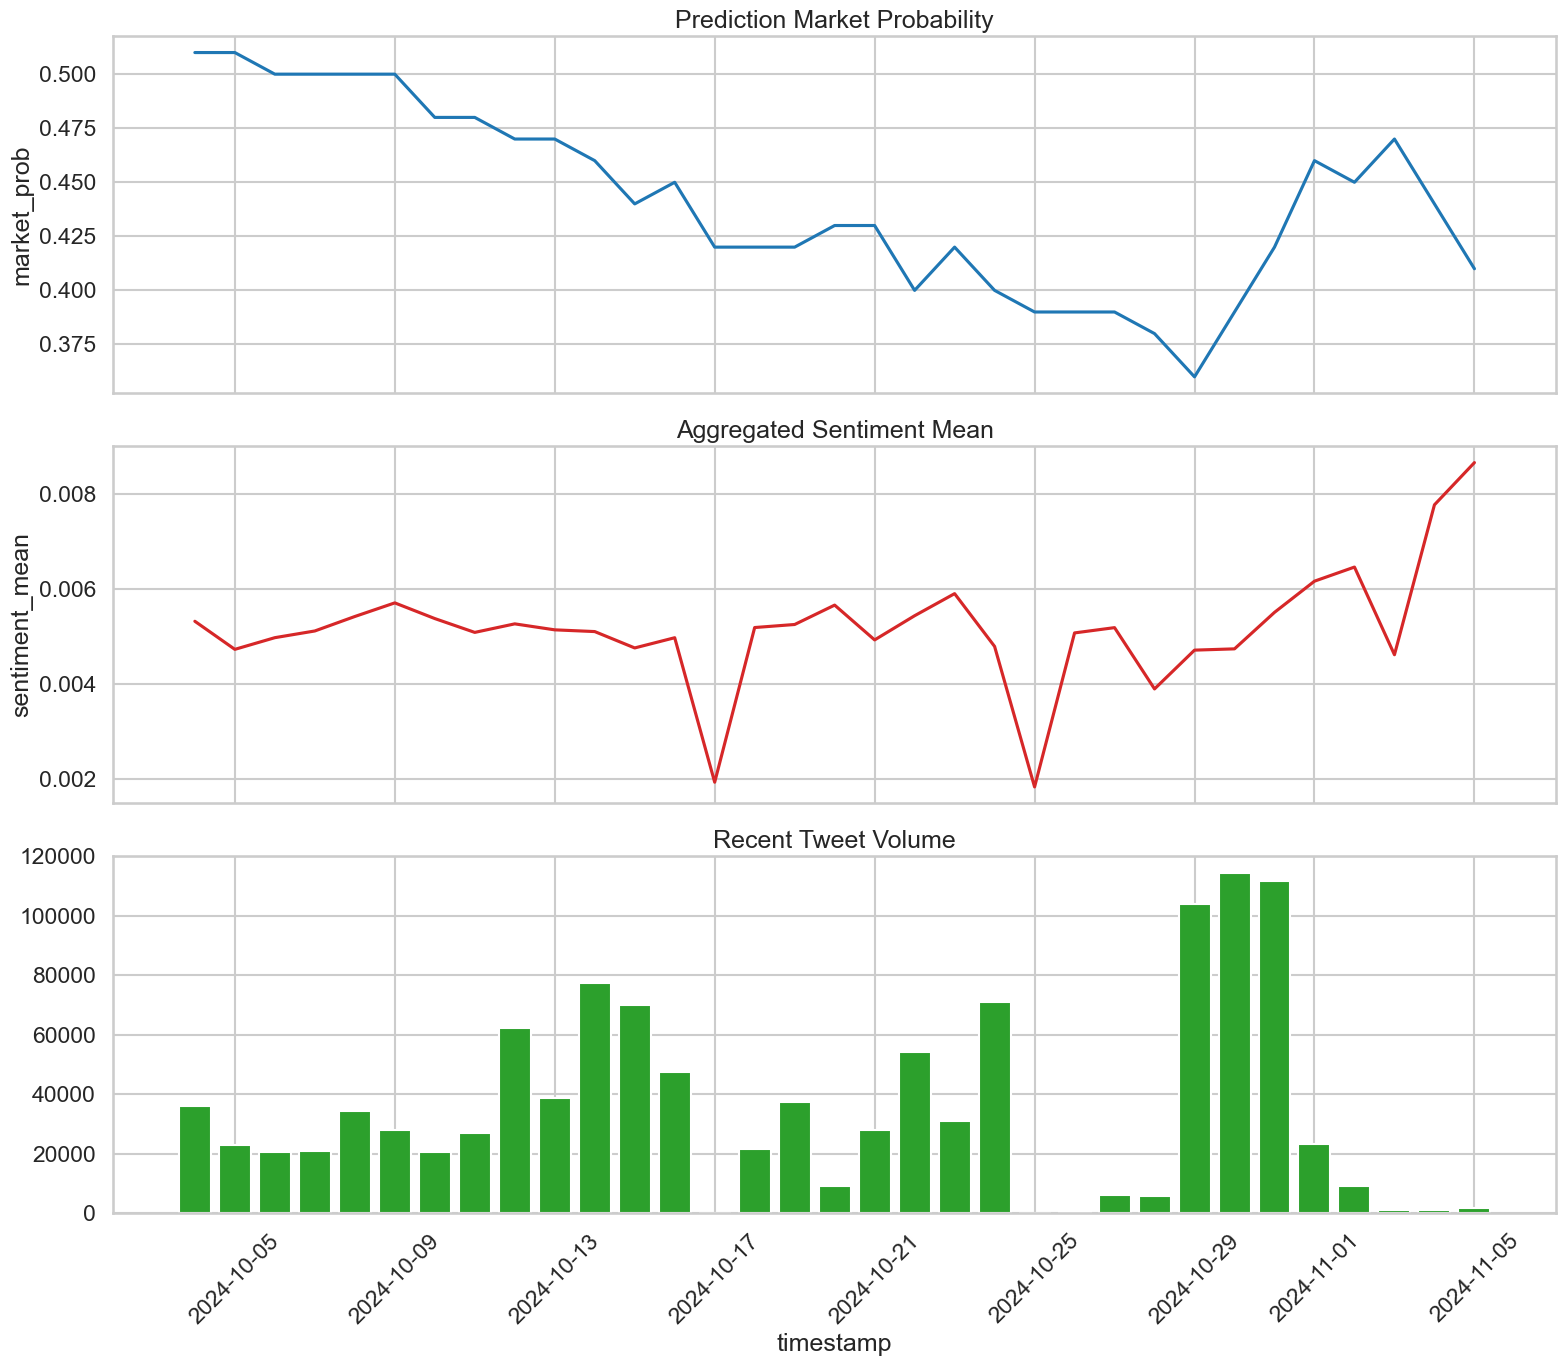

In [28]:
plot_df = model_df.copy()
plot_df["timestamp_plot"] = plot_df["timestamp"].dt.tz_convert(None)
recent_df = plot_df.tail(80)

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

sns.lineplot(data=plot_df, x="timestamp_plot", y="market_prob", ax=axes[0], color="#1f77b4")
axes[0].set_title("Prediction Market Probability")

sns.lineplot(data=plot_df, x="timestamp_plot", y="sentiment_mean", ax=axes[1], color="#d62728")
axes[1].set_title("Aggregated Sentiment Mean")

axes[2].bar(recent_df["timestamp_plot"], recent_df["tweet_count"], width=0.8, color="#2ca02c")
axes[2].set_title("Recent Tweet Volume")
axes[2].set_xlabel("timestamp")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [29]:
baseline_features = [
    "market_prob",
    "market_return_1",
    "market_return_3",
    "market_return_6",
    "market_volatility_6",
    "market_ma_3",
    "market_ma_6",
    "market_volume",
]

sentiment_features = baseline_features + [
    "sentiment_mean",
    "sentiment_std",
    "sentiment_sum",
    "tweet_count",
    "tweet_count_log1p",
    "sentiment_momentum",
    "tweet_count_change",
]

preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

regression_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", LinearRegression()),
    ]
)

classification_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

def evaluate_time_series_model(X, y, estimator, task="regression", splits=5):
    n_splits = min(splits, max(2, len(X) // 5))
    splitter = TimeSeriesSplit(n_splits=n_splits)
    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X), start=1):
        model = clone(estimator)
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if task == "classification" and y_train.nunique() < 2:
            pred_labels = np.repeat(y_train.iloc[0], len(y_test))
            fold_rows.append(
                {
                    "fold": fold,
                    "accuracy": accuracy_score(y_test, pred_labels),
                    "f1": f1_score(y_test, pred_labels, zero_division=0),
                }
            )
            continue

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        if task == "regression":
            fold_rows.append(
                {
                    "fold": fold,
                    "mse": mean_squared_error(y_test, preds),
                    "mae": mean_absolute_error(y_test, preds),
                    "r2": r2_score(y_test, preds),
                }
            )
        else:
            pred_labels = (preds >= 0.5).astype(int) if preds.ndim == 1 else np.argmax(preds, axis=1)
            fold_rows.append(
                {
                    "fold": fold,
                    "accuracy": accuracy_score(y_test, pred_labels),
                    "f1": f1_score(y_test, pred_labels, zero_division=0),
                }
            )

    return pd.DataFrame(fold_rows)

In [30]:
experiment_rows = []

for horizon in HORIZONS:
    horizon_df = add_targets(model_df, horizon=horizon)

    X_base_reg, y_reg = prepare_xy(horizon_df, baseline_features, f"target_change_h{horizon}")
    X_aug_reg, _ = prepare_xy(horizon_df, sentiment_features, f"target_change_h{horizon}")

    reg_base_scores = evaluate_time_series_model(X_base_reg, y_reg, regression_pipeline, task="regression")
    reg_aug_scores = evaluate_time_series_model(X_aug_reg, y_reg.loc[X_aug_reg.index], regression_pipeline, task="regression")

    for label, scores in [("baseline", reg_base_scores), ("sentiment_augmented", reg_aug_scores)]:
        experiment_rows.append(
            {
                "horizon_days": horizon,
                "task": "regression",
                "model_family": label,
                "mse_mean": scores["mse"].mean(),
                "mae_mean": scores["mae"].mean(),
                "r2_mean": scores["r2"].mean(),
            }
        )

    X_base_clf, y_clf = prepare_xy(horizon_df, baseline_features, f"target_direction_h{horizon}")
    X_aug_clf, _ = prepare_xy(horizon_df, sentiment_features, f"target_direction_h{horizon}")

    clf_base_scores = evaluate_time_series_model(X_base_clf, y_clf, classification_pipeline, task="classification")
    clf_aug_scores = evaluate_time_series_model(X_aug_clf, y_clf.loc[X_aug_clf.index], classification_pipeline, task="classification")

    for label, scores in [("baseline", clf_base_scores), ("sentiment_augmented", clf_aug_scores)]:
        experiment_rows.append(
            {
                "horizon_days": horizon,
                "task": "classification",
                "model_family": label,
                "accuracy_mean": scores["accuracy"].mean(),
                "f1_mean": scores["f1"].mean(),
            }
        )

results_df = pd.DataFrame(experiment_rows)
results_df

,horizon_days,task,model_family,mse_mean,mae_mean,r2_mean,accuracy_mean,f1_mean
0,1,regression,baseline,0.014879,0.077628,-70.884235,NaN,NaN
1,1,regression,sentiment_augmented,0.023297,0.117505,-637.576254,NaN,NaN
2,1,classification,baseline,NaN,NaN,NaN,0.7000,0.400000
3,1,classification,sentiment_augmented,NaN,NaN,NaN,0.7500,0.433333
4,3,regression,baseline,0.055677,0.145985,-117.881192,NaN,NaN
5,3,regression,sentiment_augmented,0.033972,0.119079,-31.997027,NaN,NaN
6,3,classification,baseline,NaN,NaN,NaN,0.6875,0.250000
7,3,classification,sentiment_augmented,NaN,NaN,NaN,0.5625,0.000000
8,7,regression,baseline,0.002674,0.042140,-18.768755,NaN,NaN
9,7,regression,sentiment_augmented,0.181331,0.235136,-1444.784278,NaN,NaN


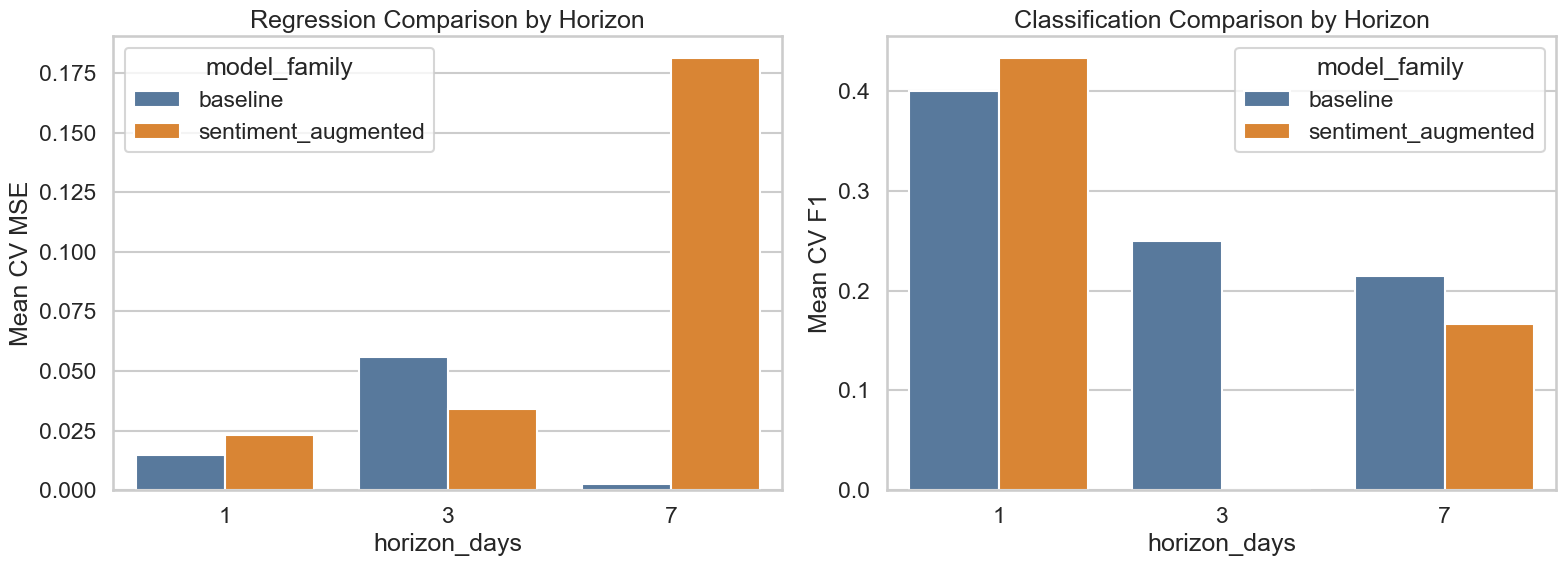

In [31]:
regression_results = results_df.query("task == 'regression'").copy()
classification_results = results_df.query("task == 'classification'").copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=regression_results,
    x="horizon_days",
    y="mse_mean",
    hue="model_family",
    ax=axes[0],
    palette=["#4c78a8", "#f58518"],
)
axes[0].set_title("Regression Comparison by Horizon")
axes[0].set_ylabel("Mean CV MSE")

sns.barplot(
    data=classification_results,
    x="horizon_days",
    y="f1_mean",
    hue="model_family",
    ax=axes[1],
    palette=["#4c78a8", "#f58518"],
)
axes[1].set_title("Classification Comparison by Horizon")
axes[1].set_ylabel("Mean CV F1")

plt.tight_layout()
plt.show()

In [ ]:
def lead_lag_analysis(frame, max_lag = 7):
    rows = []
    base = frame[["timestamp", "sentiment_mean", "market_return_1"]].dropna().copy()

    for lag in range(-max_lag, max_lag + 1):
        shifted = base["sentiment_mean"].shift(lag)
        corr = shifted.corr(base["market_return_1"])
        rows.append({"lag_days": lag, "correlation": corr})

    return pd.DataFrame(rows)

lag_df = lead_lag_analysis(model_df, max_lag=7)
lag_df

,lag_days,correlation
0,-7,-0.070515
1,-6,0.153570
2,-5,0.291576
3,-4,0.340458
4,-3,0.335236
5,-2,0.156231
6,-1,0.109143
7,0,0.007727
8,1,-0.075424
9,2,-0.232184


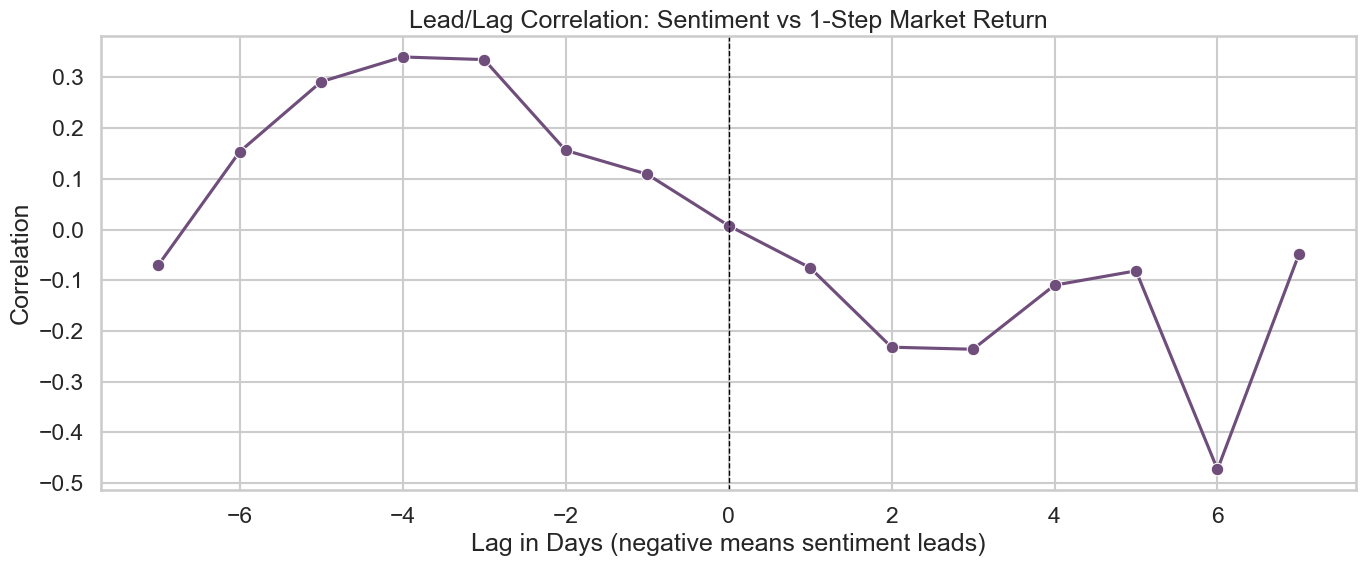

In [33]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=lag_df, x="lag_days", y="correlation", marker="o", color="#6f4e7c")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Lead/Lag Correlation: Sentiment vs 1-Step Market Return")
plt.xlabel("Lag in Days (negative means sentiment leads)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

In [34]:
results_path = PROCESSED_DIR / "model_comparison_results.csv"
lag_path = PROCESSED_DIR / "lead_lag_results.csv"

results_df.to_csv(results_path, index=False)
lag_df.to_csv(lag_path, index=False)

print("Saved:", results_path)
print("Saved:", lag_path)

Saved: /Users/izhu/sentiment-market-prediction/data/processed/model_comparison_results.csv
Saved: /Users/izhu/sentiment-market-prediction/data/processed/lead_lag_results.csv
